# VAR — Multi-Horizon WTI Forecasting

## Overview
Vector Autoregression (VAR) jointly models oil returns and selected macro variables as a system, capturing feedback effects between series. Unlike Elastic Net and XGBoost which treat macro variables as exogenous inputs, VAR treats all variables as endogenous — each variable is a linear function of its own lags and the lags of all other variables.

### Key Design Decisions
- **Feature selection via BIC**: With 31 candidate macro features, a full VAR would have an infeasible number of parameters. Greedy forward selection (max 5 features) keeps the system tractable.
- **Walk-forward evaluation**: VAR is refit at every test step (expanding window), which is the gold standard for VAR evaluation.
- **Multi-horizon via multi-step forecasting**: For h>1, we use iterated 1-step forecasts from the VAR system.
- **Daily alignment fix**: Now uses `price.index` instead of `freq="B"` to match other models exactly.

## 1. Imports

In [3]:
# ============================================================
# Imports
# ============================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import time
import warnings
from abc import ABC, abstractmethod
from typing import Dict, Tuple, Optional
from statsmodels.tsa.api import VAR
from statsmodels.tools.sm_exceptions import ValueWarning
import matplotlib.pyplot as plt
%matplotlib inline

warnings.simplefilter("ignore", ValueWarning)
warnings.filterwarnings("ignore")

## 2. Base Forecast Model

In [4]:
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type
    @abstractmethod
    def fit(self, *args, **kwargs): pass
    @abstractmethod
    def evaluate(self, *args, **kwargs): pass
    @abstractmethod
    def save(self, filepath: str): pass
    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [5]:
# ============================================================
# Evaluation Metrics
# ============================================================
def rmse(y, yhat):
    """Root Mean Squared Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    """Mean Absolute Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    """R-squared. Negative = worse than predicting the mean."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    """Fraction where predicted and actual signs match. 50% = random."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))

## 4. Data Helpers (Trading-Day Aligned)
**FIX**: The VAR notebook previously used `freq="B"` (business days), which created synthetic zero-return rows on market holidays. Now uses `price.index` (actual trading days) for consistency with XGBoost and LSTM.

In [6]:
# ============================================================
# Data Helpers — Trading-Day Aligned (FIX)
# ============================================================
def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """Load FRED-MD monthly macro data."""
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing: {missing}")
    return df[keep].copy()

def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()

def daily_log_return(price: pd.Series) -> pd.Series:
    return np.log(price.astype(float)).diff().rename("ret_1d")

## 5. VAR Frame Builder (Fixed Alignment)

In [7]:
# ============================================================
# Build VAR Frame — Trading-Day Aligned (FIX)
# ============================================================
def build_var_frame(
    macro_file: Path,
    price_file: Path,
    macro_features: list[str],
    train_end: str,
    val_end: str,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build VAR-ready dataframe aligned to WTI trading days.

    FIX: Uses price.index instead of freq='B' to avoid
    creating synthetic rows on market holidays.
    """
    # Load and shift macro (anti-leakage)
    macro_m = load_macro_monthly(macro_file, macro_features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # Load price (trading days only)
    price = load_price(price_file)

    # FIX: Align macro directly to trading-day index
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Compute returns on actual trading days
    ret = daily_log_return(price)

    # Combine
    base = macro_d.join(ret, how="inner")
    base = base.dropna(subset=["ret_1d"]).copy().sort_index()

    # Chronological split
    te, ve = pd.Timestamp(train_end), pd.Timestamp(val_end)
    return (
        base.loc[base.index <= te],
        base.loc[(base.index > te) & (base.index <= ve)],
        base.loc[base.index > ve],
    )

## 6. Naive Baseline

In [8]:
# ============================================================
# Naive Baseline — Predict Zero
# ============================================================
# The naive baseline predicts zero return for all dates.
# This is equivalent to the random walk hypothesis: P_{t+h} = P_t.
# Any model that can't beat this has no predictive value.
# R² is implicitly measured against this baseline, but having explicit
# metrics makes the comparison concrete.

def naive_baseline_metrics(y):
    """Evaluate the naive 'predict zero' baseline."""
    y = np.asarray(y, float)
    pred = np.zeros_like(y)
    return {
        "rmse": rmse(y, pred),
        "mae": mae(y, pred),
        "r2": r2(y, pred),
        "directional_acc": 0.5,  # random by definition
    }

## 7. Walk-Forward Evaluation
For each date in the evaluation set, fit VAR on all history so far and forecast. For multi-horizon (h>1), use iterated multi-step forecasting from the VAR system.

In [9]:
# ============================================================
# Walk-Forward VAR Evaluation (supports multi-horizon)
# ============================================================
def walk_forward_var(
    df_train: pd.DataFrame,
    df_eval: pd.DataFrame,
    target_col: str,
    best_lag: int,
    horizon: int = 1,
    min_train_obs: int = 500,
) -> Dict:
    """Expanding-window walk-forward evaluation.

    For horizon > 1, uses iterated multi-step forecasting.
    Returns dict with metrics and arrays of predictions.
    """
    history = df_train.copy()
    y_true, y_pred, dates = [], [], []

    for i in range(len(df_eval)):
        if len(history) < min_train_obs:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        try:
            model = VAR(history).fit(best_lag)
            # Multi-step forecast
            fc = model.forecast(history.values[-best_lag:], steps=horizon)
            # Take the h-step-ahead prediction for target column
            pred = fc[horizon - 1][history.columns.get_loc(target_col)]
        except Exception:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        # For h>1, the "true" value is the h-day cumulative log return
        # from this date forward (if available)
        if i + horizon - 1 < len(df_eval):
            actual = df_eval[target_col].iloc[i:i+horizon].sum()
        else:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        y_true.append(actual)
        y_pred.append(pred)
        dates.append(df_eval.index[i])
        history = pd.concat([history, df_eval.iloc[[i]]])

    yt = np.asarray(y_true, float)
    yp = np.asarray(y_pred, float)

    return {
        "y_true": yt, "y_pred": yp, "dates": dates,
        "best_lag": int(best_lag), "n_scored": len(yt),
        "rmse": rmse(yt, yp), "mae": mae(yt, yp),
        "r2": r2(yt, yp), "directional_acc": directional_accuracy(yt, yp),
    }

## 8. Greedy Feature Selection (BIC)

In [10]:
# ============================================================
# Greedy Forward Feature Selection (BIC)
# ============================================================
def greedy_var_feature_select(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    macro_candidates: list[str],
    target_col: str = "ret_1d",
    maxlags_grid: list[int] = [1, 2, 3, 5],
    max_features: int = 5,
    patience: int = 2,
) -> Dict:
    """Greedy forward selection using BIC on training data."""
    remaining = [c for c in macro_candidates
                 if c in df_train.columns and c in df_val.columns
                 and df_train[c].notna().any()]

    selected, history = [], []
    best_bic, no_improve = np.inf, 0

    def bic_for(feats):
        cols = [target_col] + feats
        best, bl = np.inf, None
        for lag in maxlags_grid:
            try:
                m = VAR(df_train[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best:
                    best, bl = m.bic, lag
            except: continue
        return {"bic": best, "lag": bl or maxlags_grid[0]}

    # Step 1: best single feature
    best_feat, best_res = None, None
    for f in remaining:
        res = bic_for([f])
        if np.isfinite(res["bic"]) and res["bic"] < best_bic:
            best_bic, best_feat, best_res = res["bic"], f, res
    if not best_feat:
        return {"selected_features": [], "best_val_bic": np.nan, "history": []}
    selected.append(best_feat)
    remaining.remove(best_feat)
    history.append({"added": best_feat, "score": best_res})

    # Step 2: forward selection
    while remaining and len(selected) < max_features:
        round_best, round_feat, round_res = best_bic, None, None
        for f in remaining:
            res = bic_for(selected + [f])
            if np.isfinite(res["bic"]) and res["bic"] < round_best:
                round_best, round_feat, round_res = res["bic"], f, res
        if not round_feat:
            no_improve += 1
            if no_improve >= patience: break
            continue
        best_bic = round_best
        selected.append(round_feat)
        remaining.remove(round_feat)
        history.append({"added": round_feat, "score": round_res})
        no_improve = 0

    return {"selected_features": selected, "best_val_bic": float(best_bic), "history": history}

## 9. VAR Model Class

In [11]:
# ============================================================
# VAR Forecast Model
# ============================================================
class VARForecastModel(BaseForecastModel):
    def __init__(self, maxlags_grid=[1, 2, 3, 5], target_col="ret_1d"):
        super().__init__("regression")
        self.maxlags_grid = maxlags_grid
        self.target_col = target_col
        self.selected_features_ = []
        self.best_lag_ = None

    def fit(self, df, selected_features):
        """Pick best lag via BIC on provided data."""
        self.selected_features_ = selected_features
        cols = [self.target_col] + selected_features
        best_bic, best_lag = np.inf, None
        for lag in self.maxlags_grid:
            try:
                m = VAR(df[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best_bic:
                    best_bic, best_lag = m.bic, lag
            except: continue
        self.best_lag_ = int(best_lag) if best_lag else int(self.maxlags_grid[0])
        return self

    def evaluate(self, df_train, df_test, horizon=1):
        cols = [self.target_col] + self.selected_features_
        return walk_forward_var(
            df_train[cols], df_test[cols],
            self.target_col, self.best_lag_, horizon=horizon,
        )

    def save(self, path):
        with open(path, "wb") as f: pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f: self.__dict__.update(pickle.load(f))

## 10. Configuration

In [12]:
# ============================================================
# Configuration
# ============================================================
MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
PRICE_FILE = Path("Price/Price.csv")
FEATURES = [
    "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
    "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
    "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
    "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
    "PPICMM","UMCSENTx"
]
HORIZONS = [1, 5, 20]

## 11. Build Data & Feature Selection

In [13]:
# ============================================================
# Build data and run feature selection
# ============================================================
df_tr, df_va, df_te = build_var_frame(
    MACRO_FILE, PRICE_FILE, FEATURES,
    train_end="2014-12-31", val_end="2024-12-31",
)

print("Shapes:", df_tr.shape, df_va.shape, df_te.shape)

# Feature selection (done once on train data)
sel = greedy_var_feature_select(
    df_train=df_tr, df_val=df_va,
    macro_candidates=FEATURES, target_col="ret_1d",
    maxlags_grid=[1, 2, 3, 5], max_features=5, patience=2,
)
print("Selected features:", sel["selected_features"])
print("Best BIC:", sel.get("best_val_bic"))

# Fit final model on train+val combined
df_trva = pd.concat([df_tr, df_va])
model = VARForecastModel(maxlags_grid=[1, 2, 3, 5], target_col="ret_1d")
model.fit(df_trva, sel["selected_features"])
print("Best lag:", model.best_lag_)

Shapes: (7983, 32) (2635, 32) (216, 32)
Selected features: ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']
Best BIC: -52.90484409857837
Best lag: 1


## 12. Multi-Horizon Walk-Forward Evaluation
For each horizon, run walk-forward evaluation on both validation and test sets. VAR multi-step forecasting is computationally expensive — especially at h=20.

In [14]:
# ============================================================
# Multi-Horizon Evaluation
# ============================================================
results = {}

for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f"  HORIZON = {h} day(s)")
    print(f"{'='*60}")
    t0 = time.time()

    # Validation: walk-forward using train as initial history
    cols = ["ret_1d"] + sel["selected_features"]
    val_res = walk_forward_var(
        df_tr[cols], df_va[cols], "ret_1d", model.best_lag_, horizon=h,
    )

    # Test: walk-forward using train+val as initial history
    test_res = walk_forward_var(
        df_trva[cols], df_te[cols], "ret_1d", model.best_lag_, horizon=h,
    )

    # Naive baseline
    naive_val = naive_baseline_metrics(val_res["y_true"])
    naive_test = naive_baseline_metrics(test_res["y_true"])

    elapsed = time.time() - t0

    results[h] = {
        'val_res': val_res, 'test_res': test_res,
        'naive_val': naive_val, 'naive_test': naive_test,
        'elapsed': elapsed,
    }

    print(f"  Val  (n={val_res['n_scored']}): RMSE={val_res['rmse']:.6f} "
          f"R²={val_res['r2']:.6f} DA={val_res['directional_acc']:.4f}")
    print(f"  Test (n={test_res['n_scored']}): RMSE={test_res['rmse']:.6f} "
          f"R²={test_res['r2']:.6f} DA={test_res['directional_acc']:.4f}")
    print(f"  Naive test: RMSE={naive_test['rmse']:.6f}")
    print(f"  Time: {elapsed:.1f}s")

print("\nAll horizons complete.")


  HORIZON = 1 day(s)
  Val  (n=2635): RMSE=0.030923 R²=-0.003272 DA=0.5051
  Test (n=216): RMSE=0.020606 R²=-0.011053 DA=0.5463
  Naive test: RMSE=0.020505
  Time: 57.5s

  HORIZON = 5 day(s)
  Val  (n=2631): RMSE=0.059075 R²=-0.000721 DA=0.5203
  Test (n=212): RMSE=0.048833 R²=-0.009110 DA=0.4764
  Naive test: RMSE=0.048797
  Time: 69.2s

  HORIZON = 20 day(s)
  Val  (n=2616): RMSE=0.114844 R²=-0.001256 DA=0.5122
  Test (n=197): RMSE=0.068298 R²=-0.124938 DA=0.3249
  Naive test: RMSE=0.068199
  Time: 72.9s

All horizons complete.


## 13. Comparison Table

In [15]:
# ============================================================
# Comparison Table
# ============================================================
print("\n" + "=" * 85)
print("  VAR MULTI-HORIZON COMPARISON")
print("=" * 85)

header = f"{'Horizon':>8} | {'Model':>8} | {'Split':>5} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'Dir Acc':>10}"
print(header)
print("-" * len(header))

for h in HORIZONS:
    r = results[h]
    vr, tr = r['val_res'], r['test_res']
    for model_name, vm, tm in [
        ("VAR", {k: vr[k] for k in ['rmse','mae','r2','directional_acc']},
                {k: tr[k] for k in ['rmse','mae','r2','directional_acc']}),
        ("Naive", r["naive_val"], r["naive_test"]),
    ]:
        for sn, m in [("Val", vm), ("Test", tm)]:
            print(f"  h={h:>2}d   | {model_name:>8} | {sn:>5} | "
                  f"{m['rmse']:>10.6f} | {m['mae']:>10.6f} | "
                  f"{m['r2']:>10.6f} | {m['directional_acc']:>10.4f}")
    print("-" * len(header))

print(f"\nSelected features: {sel['selected_features']}")
print(f"Best lag: {model.best_lag_}")


  VAR MULTI-HORIZON COMPARISON
 Horizon |    Model | Split |       RMSE |        MAE |         R² |    Dir Acc
-------------------------------------------------------------------------------
  h= 1d   |      VAR |   Val |   0.030923 |   0.018519 |  -0.003272 |     0.5051
  h= 1d   |      VAR |  Test |   0.020606 |   0.015161 |  -0.011053 |     0.5463
  h= 1d   |    Naive |   Val |   0.030872 |   0.018484 |  -0.000013 |     0.5000
  h= 1d   |    Naive |  Test |   0.020505 |   0.015166 |  -0.001236 |     0.5000
-------------------------------------------------------------------------------
  h= 5d   |      VAR |   Val |   0.059075 |   0.040116 |  -0.000721 |     0.5203
  h= 5d   |      VAR |  Test |   0.048833 |   0.035612 |  -0.009110 |     0.4764
  h= 5d   |    Naive |   Val |   0.059056 |   0.040115 |  -0.000097 |     0.5000
  h= 5d   |    Naive |  Test |   0.048797 |   0.035599 |  -0.007648 |     0.5000
-------------------------------------------------------------------------------


---
# Visualizations

## 14. Plot Setup

In [16]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C = {'actual': '#1a1a2e', 'pred': '#e63946', 'fill': '#a8dadc',
     'pos': '#2a9d8f', 'neg': '#e76f51', 'h1': '#264653',
     'bar1': '#264653', 'bar2': '#e76f51', 'bar3': '#a8a8a8'}

## 15. Rolling Directional Accuracy

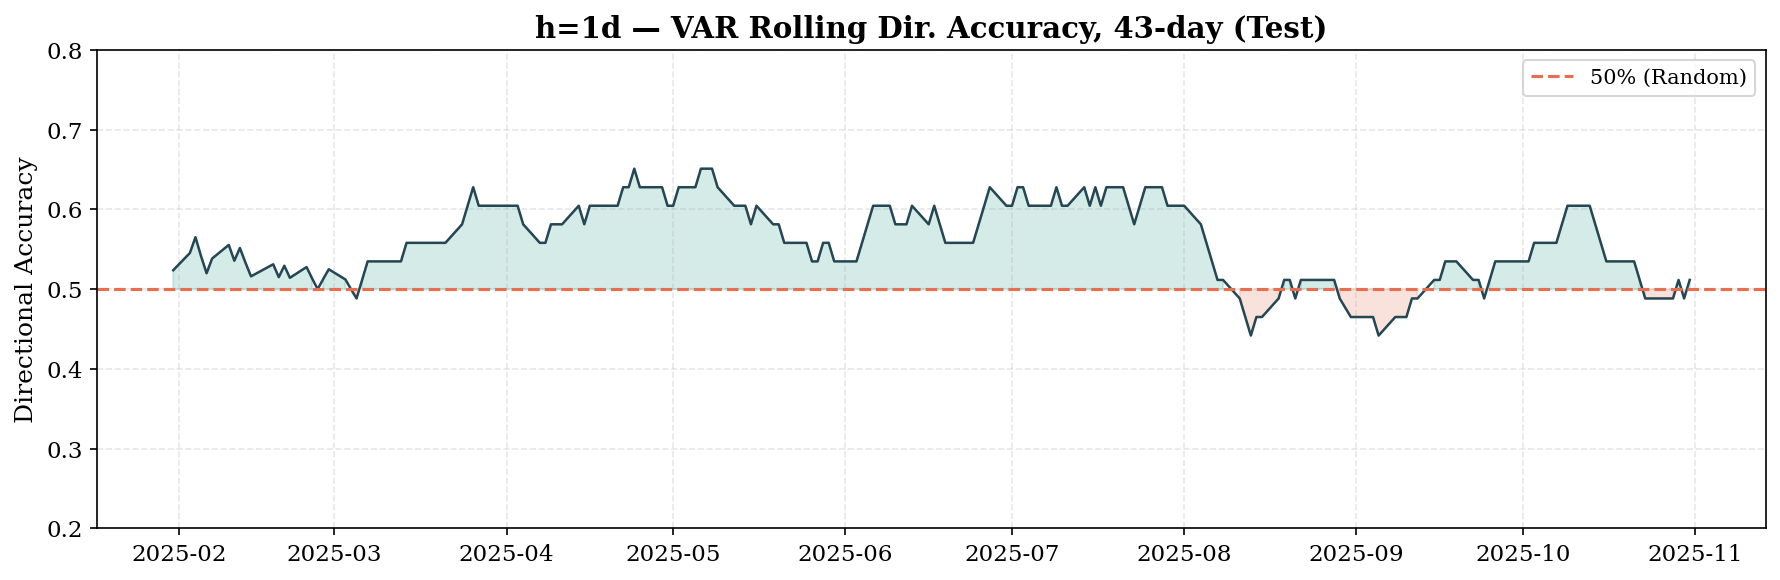

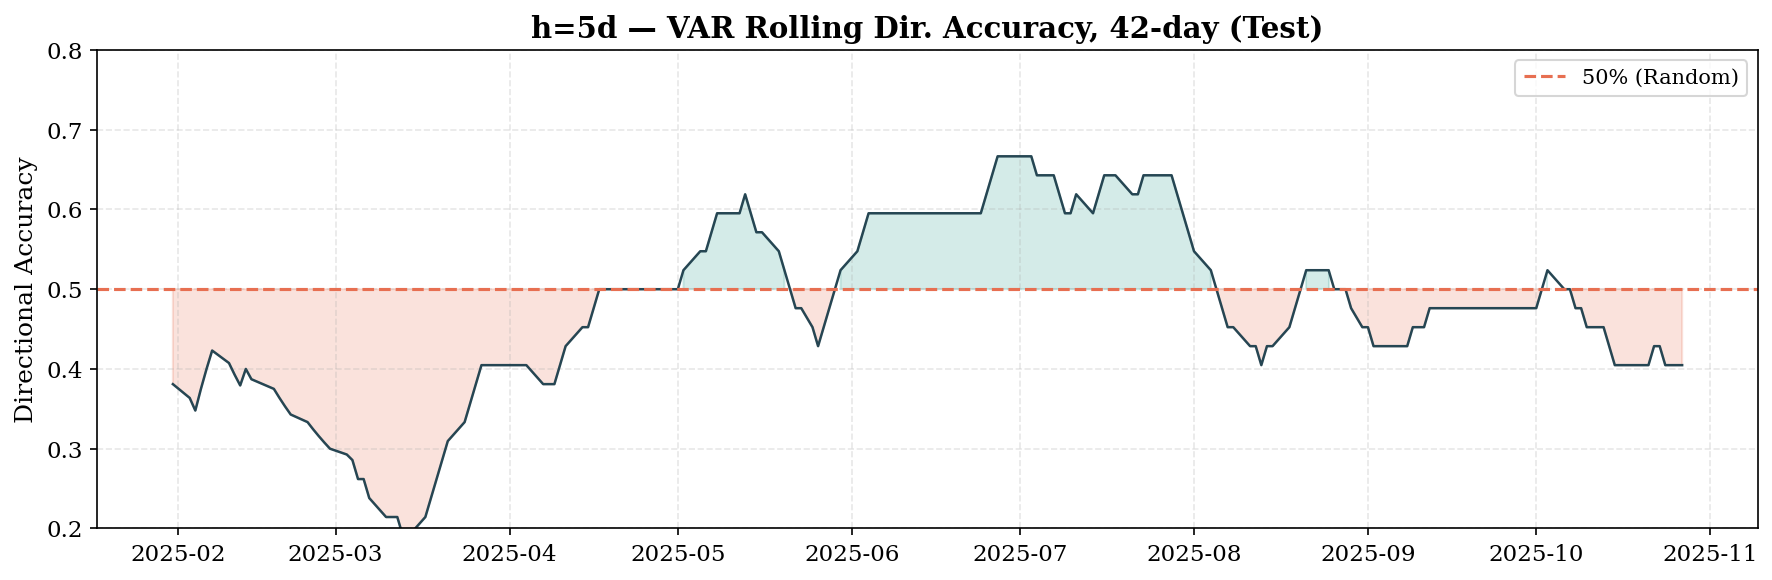

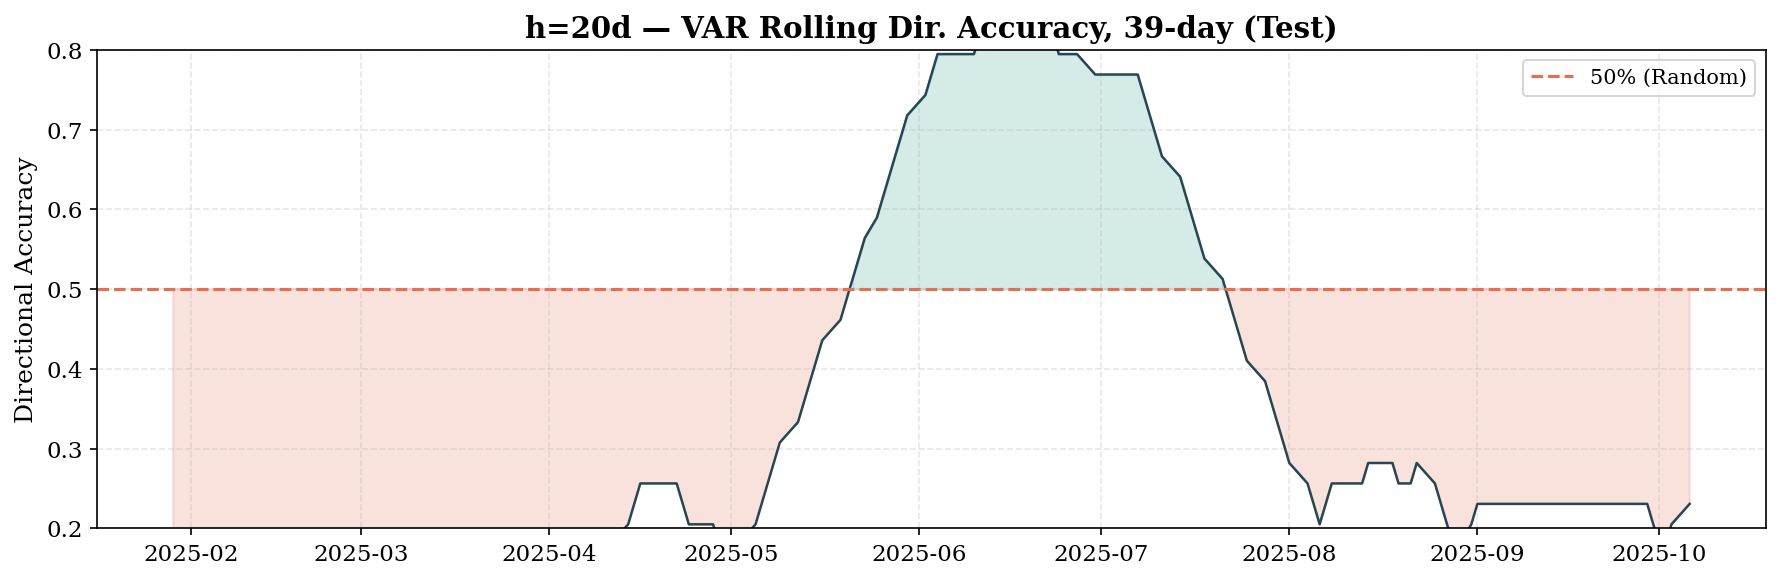

In [17]:
# ============================================================
# Rolling Directional Accuracy (Test)
# ============================================================
for h in HORIZONS:
    r = results[h]['test_res']
    if r['n_scored'] < 20: continue
    correct = (np.sign(r['y_true']) == np.sign(r['y_pred'])).astype(float)
    win = max(10, len(correct) // 5)
    roll = pd.Series(correct, index=r['dates']).rolling(win, min_periods=win//2).mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(roll, color=C['h1'], lw=1.2)
    ax.axhline(0.5, color=C['neg'], ls='--', lw=1.5, label='50% (Random)')
    ax.fill_between(roll.index, roll, 0.5, where=roll > 0.5, alpha=0.2, color=C['pos'])
    ax.fill_between(roll.index, roll, 0.5, where=roll <= 0.5, alpha=0.2, color=C['neg'])
    ax.set_ylim(0.2, 0.8)
    ax.set_title(f'h={h}d — VAR Rolling Dir. Accuracy, {win}-day (Test)', fontweight='bold')
    ax.set_ylabel('Directional Accuracy')
    ax.legend(); plt.tight_layout(); plt.show()

## 16. Residual ACF

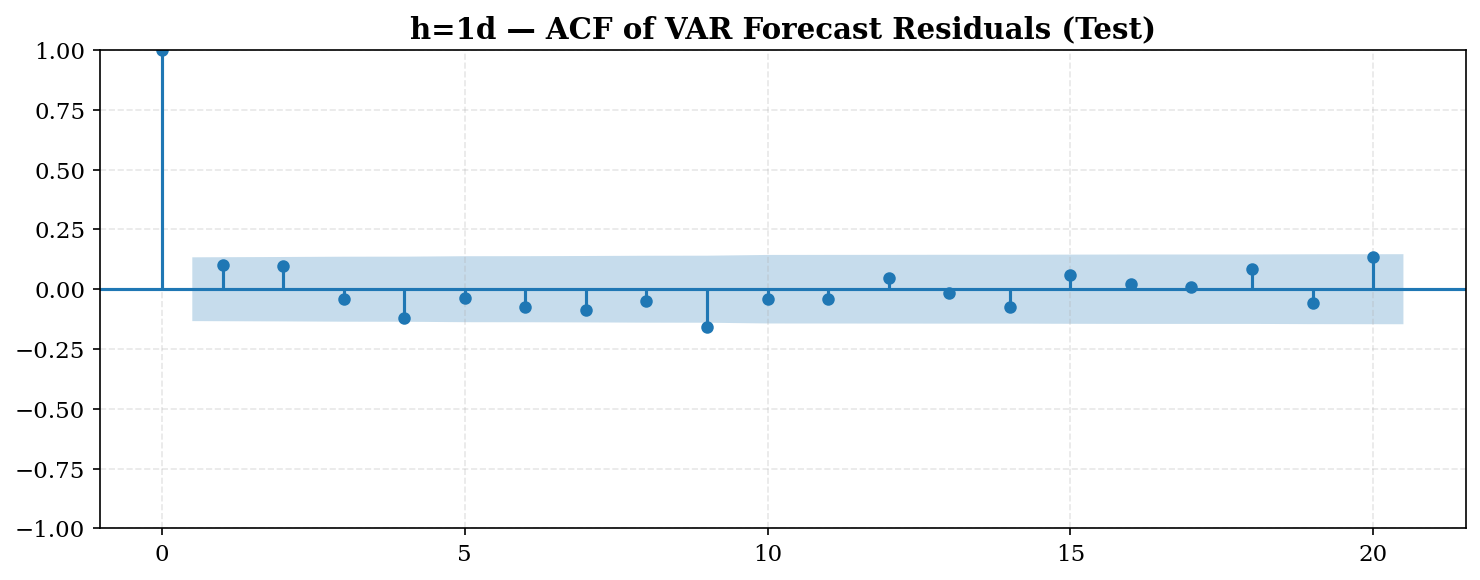

In [18]:
# ============================================================
# Residual ACF (Test, h=1)
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf

if results[1]['test_res']['n_scored'] > 20:
    residuals = results[1]['test_res']['y_true'] - results[1]['test_res']['y_pred']
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(residuals, lags=20, ax=ax)
    ax.set_title("h=1d — ACF of VAR Forecast Residuals (Test)", fontweight='bold')
    plt.tight_layout(); plt.show()

## 17. Multi-Horizon Bar Chart

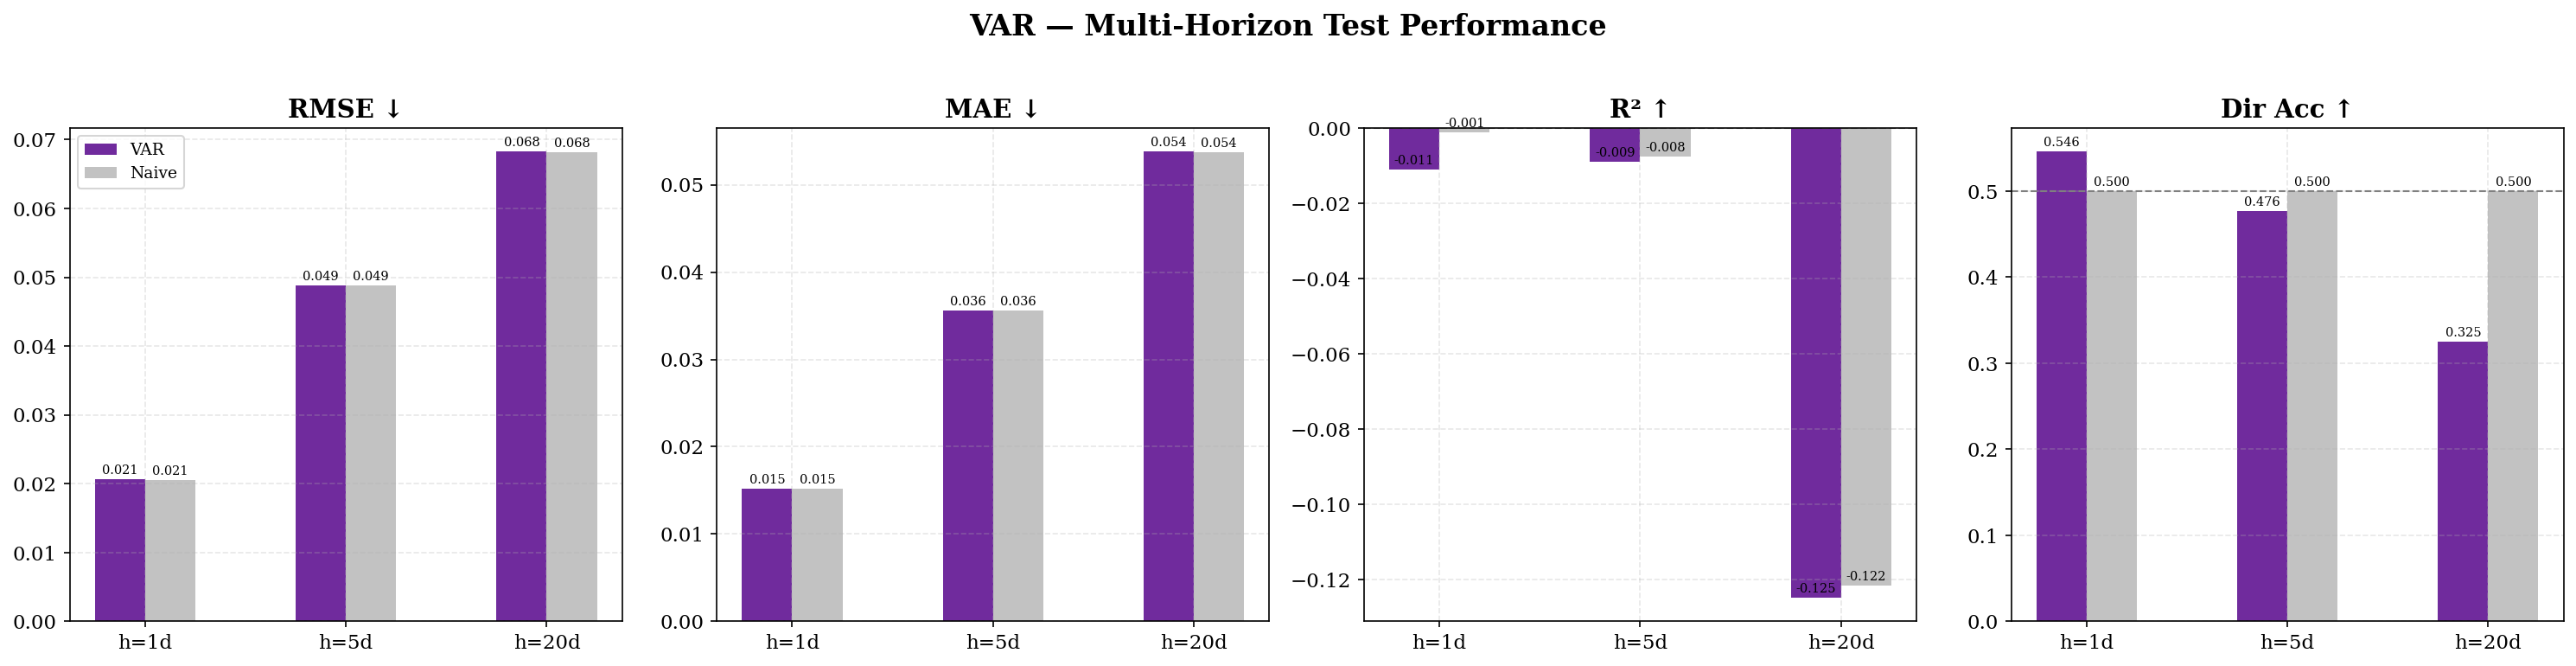

In [19]:
met_names = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Dir Acc ↑']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(HORIZONS)); w = 0.25
for i, (mn, title) in enumerate(zip(met_names, titles)):
    ax = axes[i]
    var_v = [results[h]['test_res'][mn] for h in HORIZONS]
    nv_v  = [results[h]['naive_test'][mn] for h in HORIZONS]
    b1 = ax.bar(x-w/2, var_v, w, label='VAR', color="#57068c", alpha=0.85)
    b2 = ax.bar(x+w/2, nv_v, w, label='Naive', color="#a8a8a8", alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'h={h}d' for h in HORIZONS])
    if mn == 'directional_acc': ax.axhline(0.5, color='gray', ls='--', lw=1)
    elif mn == 'r2': ax.axhline(0, color='gray', ls='--', lw=1)
    for bar in list(b1)+list(b2):
        ht=bar.get_height()
        ax.annotate(f'{ht:.3f}',xy=(bar.get_x()+bar.get_width()/2,ht),
                    xytext=(0,3),textcoords='offset points',ha='center',fontsize=7)
    if i==0: ax.legend(fontsize=9)
plt.suptitle('VAR — Multi-Horizon Test Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 18. Summary

In [18]:
rows = []
for h in HORIZONS:
    tr = results[h]['test_res']
    nt = results[h]['naive_test']
    for mn, m in [('VAR', {k: tr[k] for k in ['rmse','mae','r2','directional_acc']}),
                  ('Naive', nt)]:
        rows.append({'Horizon': f'{h}d', 'Model': mn,
            'RMSE': f"{m['rmse']:.6f}", 'MAE': f"{m['mae']:.6f}",
            'R²': f"{m['r2']:.6f}", 'Dir.Acc': f"{m['directional_acc']:.4f}"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nSelected features: {sel['selected_features']}")
print(f"Best lag: {model.best_lag_}")

Horizon Model     RMSE      MAE        R² Dir.Acc
     1d   VAR 0.020606 0.015161 -0.011053  0.5463
     1d Naive 0.020505 0.015166 -0.001236  0.5000
     5d   VAR 0.048833 0.035612 -0.009110  0.4764
     5d Naive 0.048797 0.035599 -0.007648  0.5000
    20d   VAR 0.068298 0.053833 -0.124938  0.3249
    20d Naive 0.068199 0.053723 -0.121695  0.5000

Selected features: ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']
Best lag: 1
